# Experiment: Effect of Spectroscopic vs Photometric Redshifts on the LSST Y10 PDSPL Sample

In [1]:
# =============================================================================
# Experiment: effect of spectroscopic vs photometric redshifts on the LSST Y10
# PDSPL sample.  Covers both the pairing stage (noise floor) and the
# cosmological inference stage (Appendix B of the paper).
# =============================================================================

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM, Flatw0waCDM
from tqdm import tqdm
import warnings
import os
import pickle

from pdspl_utils.data_utils import preprocess_ggl_table
from pdspl_utils.pairing import (
    get_kdtree_pairs,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
    eval_scatter_model,
    plot_beta_E_vs_D_MC,
)
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.plotting import plot_dspl_corner

warnings.filterwarnings("ignore")

POSTERIOR_DIRECTORY = "../data/posteriors/forecast_w0waCDM_fixed_scatter"
FIGURE_DIRECTORY    = "../figures/forecasts/w0waCDM_fixed_scatter"
os.makedirs(POSTERIOR_DIRECTORY, exist_ok=True)
os.makedirs(FIGURE_DIRECTORY,    exist_ok=True)

%load_ext autoreload
%autoreload 2

In [3]:
# ── Cell 2: Global configuration ─────────────────────────────────────────────
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)


# ── Cell 3: Load catalog ──────────────────────────────────────────────────────
GGL_table_LSST_Y10 = preprocess_ggl_table(
    "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"
)

In [4]:

# ── Cell 4: Sample and pairing configuration ──────────────────────────────────
#
# Two variants of LSST Y10 — same catalog, different redshift error assumptions:
#   photo_z: σ_z/(1+z) = 0.03  (photometric)
#   spec_z : σ_z        = 1e-4 (spectroscopic)
#
# Pairing features: same as notebook 03 (log-flux / log-flux-ratio + log-metric).
# Dissimilarity: same RMS metric on relative flux differences.

pdspl_samples_expt = {
    "lsst_y10_photo_z": {
        "table": GGL_table_LSST_Y10,
        "name":  r"LSST Y10 ($z_{D}^{\rm photo}$)",
        "color": "tab:green",
    },
    "lsst_y10_spec_z": {
        "table": GGL_table_LSST_Y10,
        "name":  r"LSST Y10 ($z_{D}^{\rm spec}$)",
        "color": "tab:blue",
    },
}

base_pairing_keys = [
    "z_D", "R_e_arcsec",
    "flux_D_i", "flux_ratio_D_gr", "flux_ratio_D_ri",
]
base_dissim_keys = [
    "rel_diff_z_D", "rel_diff_R_e_arcsec",
    "rel_diff_flux_D_i", "rel_diff_flux_ratio_D_gr", "rel_diff_flux_ratio_D_ri",
]
base_error_config = {
    "sigma_v_D":       10.0,
    "R_e_arcsec":      lambda t: 0.05  * t["R_e_arcsec"],
    "flux_D_i":        lambda t: 0.01  * t["flux_D_i"],
    "flux_ratio_D_gr": lambda t: 0.014 * t["flux_ratio_D_gr"],
    "flux_ratio_D_ri": lambda t: 0.014 * t["flux_ratio_D_ri"],
}

for key, s in pdspl_samples_expt.items():
    s["pairing_keys"]      = base_pairing_keys
    s["dissimilarity_keys"] = base_dissim_keys
    s["error_config"]      = base_error_config.copy()

pdspl_samples_expt["lsst_y10_photo_z"]["error_config"]["z_D"] = \
    lambda t: 0.03 * (1 + t["z_D"])
pdspl_samples_expt["lsst_y10_spec_z"]["error_config"]["z_D"] = 1e-4



In [6]:

# ── Cell 5: Monte Carlo pairing (500 realisations) ────────────────────────────
N_realizations    = 500          # match main notebook 03
METRIC            = "rms"
MAX_DISSIMILARITY = 0.15

mc_results_expt = {
    k: {
        "binned_dissim":     [],
        "binned_scatter":    [],
        "num_pairs":         [],
        "scatter_in_beta_E": [],
    }
    for k in pdspl_samples_expt
}

for i_realization in tqdm(range(N_realizations), desc="MC Realizations"):
    for sample_key, s in pdspl_samples_expt.items():
        if len(s["table"]) < 2:
            continue

        table_err = inject_observational_errors(s["table"], s["error_config"])

        # log-metric kD-Tree — consistent with notebook 03
        indices, _ = get_kdtree_pairs(
            table_err, s["pairing_keys"], use_log_metric=True
        )

        pairs_table     = get_pairs_table_PDSPL(s["table"],  indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err,   indices, cosmo_true)

        pairs_table_err["dissimilarity"] = compute_dissimilarity(
            pairs_table_err, s["dissimilarity_keys"], method=METRIC
        )

        s["pairs_analysis"] = {
            "pairs_table":              pairs_table,
            "pairs_table_with_errors":  pairs_table_err,
            "num_lenses":               len(s["table"]),
            "num_pairs":                len(pairs_table),
            "scatter_in_beta_E":        np.std(pairs_table["rel_diff_beta_E"]),
            "pair_indices":             indices,
        }

        mc_results_expt[sample_key]["num_pairs"].append(len(pairs_table))
        mc_results_expt[sample_key]["scatter_in_beta_E"].append(
            np.std(pairs_table["rel_diff_beta_E"])
        )

        mask          = (pairs_table_err["dissimilarity"] < MAX_DISSIMILARITY) & \
                        np.isfinite(pairs_table["rel_diff_beta_E"])
        dissim_masked = pairs_table_err["dissimilarity"][mask]
        delta_masked  = pairs_table["rel_diff_beta_E"][mask]

        percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
        digitized   = np.digitize(dissim_masked, percentiles)

        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bm = digitized == i
            run_dissim.append(np.median(dissim_masked[bm])  if np.any(bm) else np.nan)
            run_scatter.append(np.nanstd(delta_masked[bm])  if np.any(bm) else np.nan)

        mc_results_expt[sample_key]["binned_dissim"].append(run_dissim)
        mc_results_expt[sample_key]["binned_scatter"].append(run_scatter)

# Store means
for sample_key, s in pdspl_samples_expt.items():
    s["pairs_analysis"]["mean_num_pairs"] = np.nanmean(
        mc_results_expt[sample_key]["num_pairs"]
    )
    s["pairs_analysis"]["mean_scatter_in_beta_E"] = np.nanmean(
        mc_results_expt[sample_key]["scatter_in_beta_E"]
    )


MC Realizations:   0%|          | 0/500 [00:00<?, ?it/s]

MC Realizations: 100%|██████████| 500/500 [12:37<00:00,  1.51s/it]


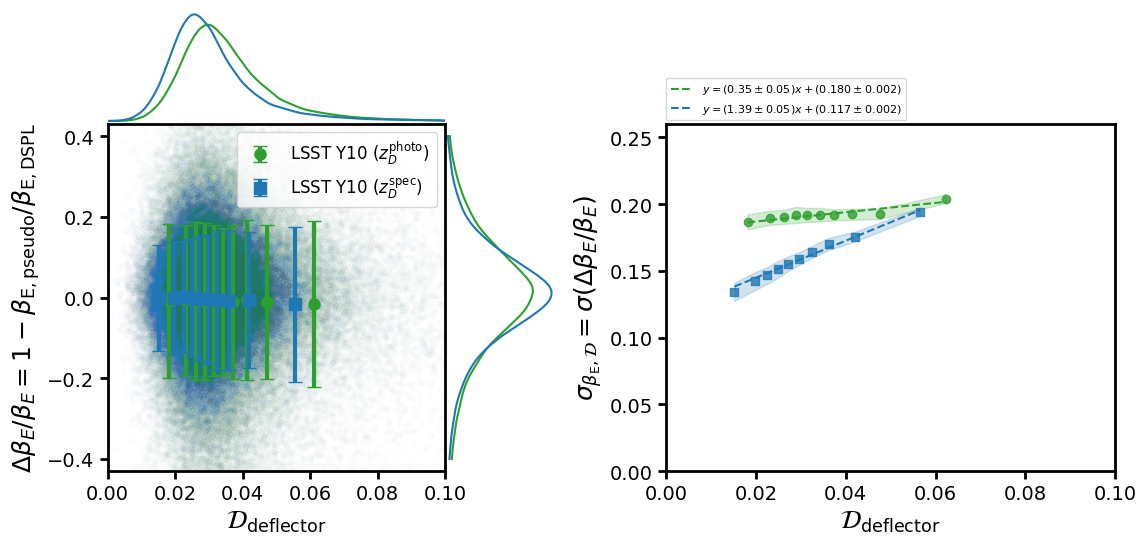


Quadrature fit coefficients for photo-z vs spec-z experiment:
  LSST Y10 ($z_{D}^{\rm photo}$): c0_floor=0.1799, c1_slope=0.3488
  LSST Y10 ($z_{D}^{\rm spec}$): c0_floor=0.1171, c1_slope=1.3853


In [14]:
# ── Cell 6: Scatter vs dissimilarity plot (quadrature fit) ───────────────────
fig_beta_D = plot_beta_E_vs_D_MC(
    pdspl_samples_expt,
    mc_results_expt,
    fit_type="linear",
    show_fit_eqn_label=True,
    save_path="../figures/beta_E_vs_D_LSST_Y10_photo_vs_spec-z.png",
)
plt.show()

# Print calibrated coefficients
print("\nQuadrature fit coefficients for photo-z vs spec-z experiment:")
for key, s in pdspl_samples_expt.items():
    pa      = s["pairs_analysis"]
    coeffs  = pa["scatter_vs_dissimilarity_fit_coeffs"]
    ft      = pa["scatter_vs_dissimilarity_fit_type"]
    print(f"  {s['name']}: c0_floor={coeffs[1]:.4f}, c1_slope={coeffs[0]:.4f}")


In [8]:
# ── Cell 7: Inference setup ───────────────────────────────────────────────────
truth = {
    "h0": 70.0, "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int":  1.0,  "lambda_sigma": 0.05,
    "gamma_pl":    2.0,  "gamma_sigma":  0.16,
}
fixed_params = {"h0": 70.0}
cosmo_true_w = Flatw0waCDM(H0=truth["h0"], Om0=truth["om"], w0=truth["w0"], wa=truth["wa"])

# Load the already-computed baseline LSST Y10 (photo-z) posterior from notebook 04a
with open("../data/samples/forecast_scenarios_w0waCDM_fixed_scatter.pkl", "rb") as f:
    saved_scenarios = pickle.load(f)
baseline_y10_samples = saved_scenarios["lsst_y10"]["samples"]

In [9]:
# ── Cell 8: Scenario definitions for inference ────────────────────────────────
#
# Two new scenarios built on the spec-z pairing from this notebook.
# The dissimilarity scatter coefficients come from the quadrature fit above.

specz_data = pdspl_samples_expt["lsst_y10_spec_z"]["pairs_analysis"]
down_sampling_factor = len(specz_data["pairs_table"]) / 2000

scenarios_to_run = {
    "lsst_y10_zD_spec": {
        "name":                    r"LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)",
        "down_sampling":           down_sampling_factor,
        "num_lenses":              len(specz_data["pairs_table"]),
        "coeffs":                  specz_data["scatter_vs_dissimilarity_fit_coeffs"],
        "fit_type":                specz_data["scatter_vs_dissimilarity_fit_type"],
        "pairs_table":             specz_data["pairs_table"],
        "pairs_table_with_errors": specz_data["pairs_table_with_errors"],
        # spec-z for deflector, photo-z for both sources
        "redshift_error_rel":      [0.0001, 0.03, 0.03],
        "backend_path":            os.path.join(POSTERIOR_DIRECTORY, "lsst_y10_zD_spec.h5"),
        "color":                   "tab:blue",
    },
    "lsst_y10_all_spec": {
        "name":                    r"LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)",
        "down_sampling":           down_sampling_factor,
        "num_lenses":              len(specz_data["pairs_table"]),
        "coeffs":                  specz_data["scatter_vs_dissimilarity_fit_coeffs"],
        "fit_type":                specz_data["scatter_vs_dissimilarity_fit_type"],
        "pairs_table":             specz_data["pairs_table"],
        "pairs_table_with_errors": specz_data["pairs_table_with_errors"],
        # spec-z for everything
        "redshift_error_rel":      [0.0001, 0.0001, 0.0001],
        "backend_path":            os.path.join(POSTERIOR_DIRECTORY, "lsst_y10_all_spec.h5"),
        "color":                   "#652e03",
    },
}

In [10]:
# ── Cell 9: Generate Asimov mock datasets ─────────────────────────────────────
print("\n--- Generating mock datasets ---")
for key, sc in scenarios_to_run.items():
    num_samples    = int(sc["num_lenses"] / sc["down_sampling"])
    coeffs         = sc["coeffs"]
    ft             = sc["fit_type"]
    random_indices = np.random.choice(len(sc["pairs_table"]), size=num_samples, replace=False)
    kwargs_list    = []

    print(f"Generating {num_samples} systems for: {sc['name']}")
    for i in random_indices:
        z_lens        = sc["pairs_table"]["z_D"][i]
        z1            = sc["pairs_table"]["z_S1"][i]
        z2            = sc["pairs_table"]["z_S2"][i]
        dissimilarity = sc["pairs_table_with_errors"]["dissimilarity"][i]

        sigma_beta_intrinsic = eval_scatter_model(coeffs, ft, dissimilarity)
        sigma_meas_rel       = np.sqrt(0.01 ** 2 + 0.01 ** 2)

        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
            gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
            sigma_beta_intrinsic=sigma_beta_intrinsic,
            sigma_meas_rel=sigma_meas_rel,
            dissimilarity=dissimilarity,
            down_sampling=sc["down_sampling"],
            with_noise=False,
            cosmo=cosmo_true_w,
            redshift_error_rel=sc["redshift_error_rel"],
        ))

    sc["kwargs_list"] = kwargs_list


--- Generating mock datasets ---
Generating 2000 systems for: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)
Generating 2000 systems for: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)


In [11]:
# ── Cell 10: MCMC inference ───────────────────────────────────────────────────
my_guess = {
    "om":  0.3,  "w0":  -1.0, "wa":  0.0,
    "lambda_int":   1.0,  "lambda_sigma": 0.05,
    "gamma_pl":     2.0,  "gamma_sigma":  0.16,
}
my_spreads = {
    "om":  0.1,  "w0":  0.1, "wa": 0.1,
    "lambda_int":   0.1, "lambda_sigma": 0.01,
    "gamma_pl":     0.1, "gamma_sigma":  0.01,
}
my_priors = {
    "h0":           ("uniform", 50.0, 90.0),
    "om":           ("uniform",  0.0,  1.0),
    "w0":           ("uniform", -3.0,  0.0),
    "wa":           ("uniform", -5.0,  5.0),
    "lambda_int":   ("uniform",  0.8,  1.2),
    "lambda_sigma": ("uniform",  0.0,  0.2),
    "gamma_pl":     ("uniform",  1.0,  3.0),
    "gamma_sigma":  ("uniform",  0.0,  0.5),
}

print("\n--- MCMC inference ---")
labels = None
for key, sc in scenarios_to_run.items():
    print(f"\nRunning: {sc['name']}")
    coeffs = sc["coeffs"]

    fixed_params_sc = fixed_params.copy()
    fixed_params_sc["beta_c0"] = coeffs[1]   # c0_floor
    fixed_params_sc["beta_c1"] = coeffs[0]   # c1_slope
    fixed_params_sc["beta_c2"] = 0.0

    samples, labels = run_dspl_inference(
        sc["kwargs_list"],
        n_walkers=64, n_steps=2000, n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params_sc,
        initial_scatter=my_spreads,
        priors=my_priors,
        backend_path=sc["backend_path"],
    )
    sc["samples"] = samples
    print(f"  → {sc['name']} DONE")

print("\n--- Inference complete ---")


--- MCMC inference ---

Running: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


100%|██████████| 2000/2000 [11:55<00:00,  2.79it/s]


  → LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm phot}$) DONE

Running: LSST Y10 ($z_{D}^{\rm spec}$, $z_{S}^{\rm spec}$)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c0', 'beta_c1', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']


 83%|████████▎ | 1664/2000 [10:00<02:01,  2.77it/s]

emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:emcee: Exception while calling your likelihood function:

Exception ignored in: 

emcee: Exception while calling your likelihood function:



<bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f99162c3770>>

KeyboardInterrupt: 

In [ ]:
# ── Cell 11: Corner plot comparison ──────────────────────────────────────────
# Combine baseline (from 04a) with the two new scenarios
scenarios_to_plot = {
    "lsst_y10_baseline": {
        "name":    r"PDSPL LSST Y10 ($z_{D}^{\rm phot}$, $z_{S}^{\rm phot}$)",
        "samples": baseline_y10_samples,
        "color":   "tab:green",
    },
    "lsst_y10_zD_spec": {
        "name":    scenarios_to_run["lsst_y10_zD_spec"]["name"],
        "samples": scenarios_to_run["lsst_y10_zD_spec"]["samples"],
        "color":   scenarios_to_run["lsst_y10_zD_spec"]["color"],
    },
    "lsst_y10_all_spec": {
        "name":    scenarios_to_run["lsst_y10_all_spec"]["name"],
        "samples": scenarios_to_run["lsst_y10_all_spec"]["samples"],
        "color":   scenarios_to_run["lsst_y10_all_spec"]["color"],
    },
}

latex_labels = {
    "om":           r"$\Omega_{\rm m}$",
    "w0":           r"$w_0$",
    "wa":           r"$w_a$",
    "lambda_int":   r"$\overline{\lambda}_{\rm MST}$",
    "lambda_sigma": r"$\sigma({\lambda}_{\rm MST})$",
    "gamma_pl":     r"$\overline{\gamma}_{\rm pl}$",
    "gamma_sigma":  r"$\sigma({\gamma}_{\rm pl})$",
}
custom_ranges = [
    (0, 1), (-2, 0), (-3, 3),
    (truth["lambda_int"] - 0.1, truth["lambda_int"] + 0.1),
    (0.0, 0.15),
    (truth["gamma_pl"] - 0.1,   truth["gamma_pl"]  + 0.1),
    (0.12, 0.22),
]
plot_keys = ["lsst_y10_baseline", "lsst_y10_zD_spec", "lsst_y10_all_spec"]

fig = plot_dspl_corner(
    scenarios=scenarios_to_plot, truth=truth, fixed_params=fixed_params,
    scenarios_to_plot=plot_keys,
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict={k: scenarios_to_plot[k]["color"] for k in plot_keys},
    save_path=os.path.join(FIGURE_DIRECTORY, "lsst_y10_photoz_vs_specz_forecast.pdf"),
)
plt.show()

# Print constraints
for key in plot_keys:
    print(f"\nConstraints for {scenarios_to_plot[key]['name']}:")
    for i, lbl in enumerate(labels):
        q16, q50, q84 = np.percentile(scenarios_to_plot[key]["samples"][:, i], [16, 50, 84])
        print(f"  {lbl}: {q50:.3f} (+{q84-q50:.3f} / -{q50-q16:.3f})")



In [ ]:
# ── Cell 12: Save intermediate results ───────────────────────────────────────
with open("../data/samples/mc_results_photo_vs_specz.pkl", "wb") as f:
    pickle.dump(mc_results_expt, f)

with open("../data/samples/forecast_scenarios_photo_vs_specz.pkl", "wb") as f:
    pickle.dump(scenarios_to_plot, f)

# Also save pdspl_samples_expt for use in 06b figure generation
pdspl_samples_expt_to_save = {
    k: {kk: vv for kk, vv in s.items() if kk != "error_config"}
    for k, s in pdspl_samples_expt.items()
}
with open("../data/samples/pdspl_samples_expt_photo_vs_specz.pkl", "wb") as f:
    pickle.dump(pdspl_samples_expt_to_save, f)

print("Saved mc_results_photo_vs_specz.pkl, forecast_scenarios_photo_vs_specz.pkl, "
      "pdspl_samples_expt_photo_vs_specz.pkl")